<a href="https://colab.research.google.com/github/anshi-tech/DataScience-project/blob/main/CrimePatternAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from folium import Map, Marker, CircleMarker, TileLayer
import folium

In [ ]:
data = pd.read_csv('crime_dataset_india.csv')
print(data.head())


   Report Number     Date Reported Date of Occurrence Time of Occurrence  \
0              1  02-01-2020 00:00   01-01-2020 00:00   01-01-2020 01:11   
1              2  01-01-2020 19:00   01-01-2020 01:00   01-01-2020 06:26   
2              3  02-01-2020 05:00   01-01-2020 02:00   01-01-2020 14:30   
3              4  01-01-2020 05:00   01-01-2020 03:00   01-01-2020 14:46   
4              5  01-01-2020 21:00   01-01-2020 04:00   01-01-2020 16:51   

        City  Crime Code Crime Description  Victim Age Victim Gender  \
0  Ahmedabad         576    IDENTITY THEFT          16             M   
1    Chennai         128          HOMICIDE          37             M   
2   Ludhiana         271        KIDNAPPING          48             F   
3       Pune         170          BURGLARY          49             F   
4       Pune         421         VANDALISM          30             F   

    Weapon Used   Crime Domain  Police Deployed Case Closed  Date Case Closed  
0  Blunt Object  Violent Crime

In [ ]:
data = data.dropna(subset =['Date Case Closed'] )
data['Date of Occurrence'] = pd.to_datetime(data['Date of Occurrence'])
data['Year'] = data['Date of Occurrence'].dt.year
data['Month'] = data['Date of Occurrence'].dt.month
data['Day'] = data['Date of Occurrence'].dt.day

/tmp/ipykernel_6330/2572383766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_counts.index, y=crime_counts.values, palette='viridis')


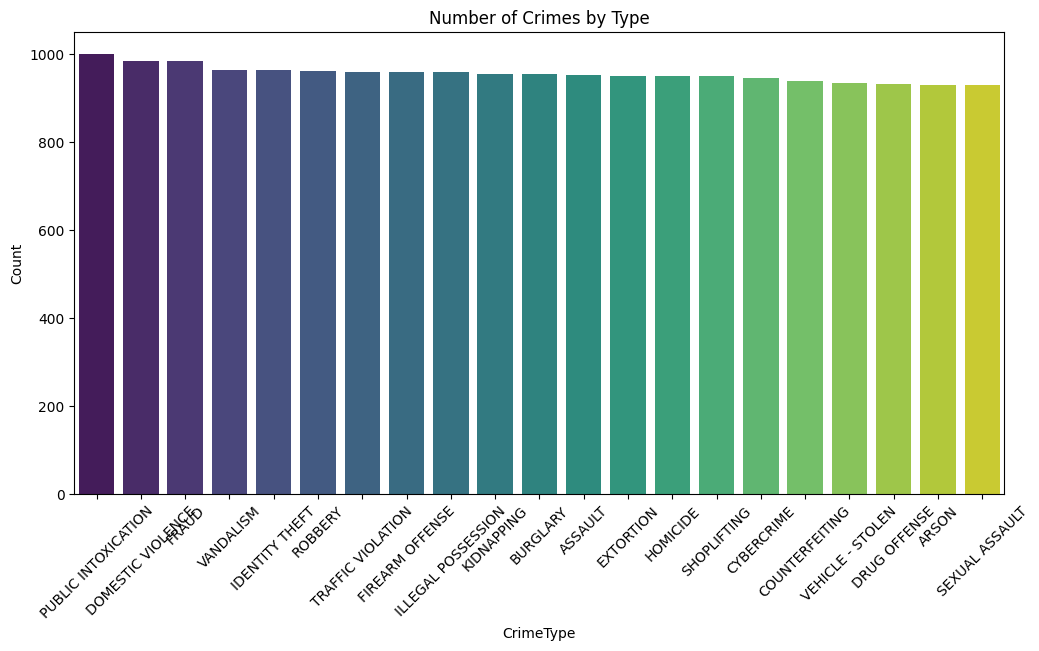

In [ ]:
crime_counts = data['Crime Description'].value_counts()
plt.figure(figsize=(12,6))

sns.barplot(x=crime_counts.index, y=crime_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Number of Crimes by Type')
plt.xlabel('CrimeType')
plt.ylabel('Count')
plt.show()

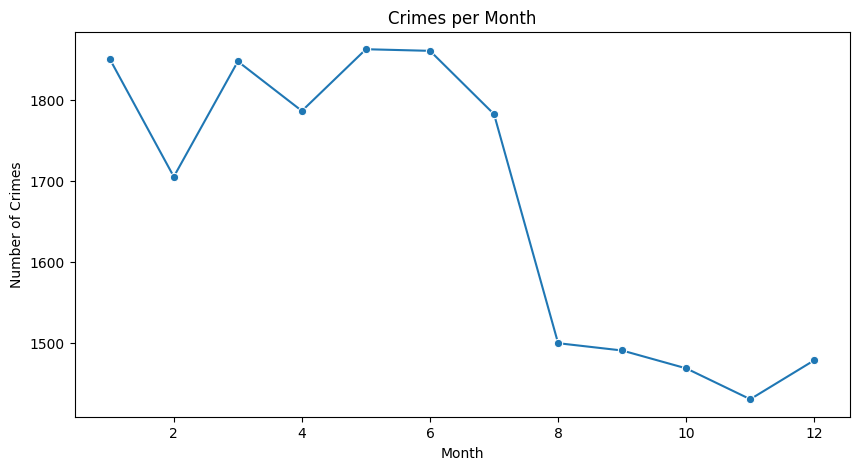

In [ ]:
monthly_counts = data.groupby('Month').size()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o')
plt.title('Crimes per Month')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.show()

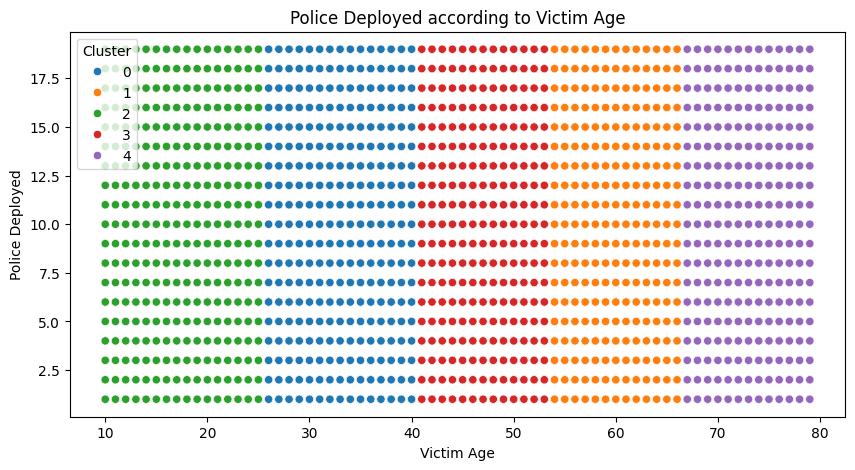

In [ ]:
#the new dataset is coords
coords = data[['Victim Age','Police Deployed']]
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(coords)

plt.figure(figsize=(10,5))
sns.scatterplot(x='Victim Age', y='Police Deployed',hue='Cluster', data=data, palette='tab10')
plt.title('Police Deployed according to Victim Age')
plt.show()

In [ ]:
#In this dataset, we can't find crime map because we need longitude and latitude in numeric form and in this we are having only one parameter which is city
crime_VictimAge_PoliceDeployed = folium.Map(location=[data['Victim Age'].mean(),data['Police Deployed'].mean()],zoom_start=12)
for idx, row in data.iterrows():
  CircleMarker(
      location=(row['Victim Age'], row['Police Deployed']),
      radius=3,
      color='red',
      fill=True,
      fill_opacity=0.6
  ).add_to(crime_VictimAge_PoliceDeployed)
  crime_VictimAge_PoliceDeployed.save('crime_VictimAge_PoliceDeployed.html')